### Import libraries

Load the tools used in this project: pandas and numpy for data, scikit-learn for the model, and matplotlib for charts.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict, StratifiedKFold

os.makedirs("images", exist_ok=True)
RS = 42        

### Load the data



In [2]:
df = pd.read_excel("Mela_Leads_Dataset_Final.xlsx",
                   dtype={"Phone": str, "Alt_Phone": str})
print(df.shape)   # (113, 9)
df.head()

(113, 9)


,ID,Name,Phone,Alt_Phone,Location,Ward,Interest,Source_File,Remarks
0,1,Krishna Karki,9851184642,NaN,Haraicha,NaN,Content Creation,Mela_Lead,NaN
1,2,Sarjak Gautam,9840513335,NaN,Itahari,NaN,"Digital Marketing, Video Editing",Mela_Lead,NaN
2,3,Happy Dev,9825382722,NaN,Biratnagar,NaN,AI Tools,Mela_Lead,NaN
3,4,Pema Ale Magar,9862355382,NaN,Sundar Haraicha,NaN,"Digital Marketing, Career Counseling",Mela_Lead,NaN
4,5,Nirmal KC,9842156250,NaN,Basantapur,NaN,Other,Mela_Lead,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           113 non-null    int64  
 1   Name         113 non-null    str    
 2   Phone        113 non-null    str    
 3   Alt_Phone    1 non-null      str    
 4   Location     113 non-null    str    
 5   Ward         39 non-null     float64
 6   Interest     113 non-null    str    
 7   Source_File  113 non-null    str    
 8   Remarks      12 non-null     str    
dtypes: float64(1), int64(1), str(7)
memory usage: 8.1 KB


In [4]:
df.describe()

,ID,Ward
count,113.00000,39.000000
mean,57.00000,6.717949
std,32.76431,4.952133
min,1.00000,1.000000
25%,29.00000,2.000000
50%,57.00000,6.000000
75%,85.00000,9.500000
max,113.00000,18.000000


In [5]:
df.isnull()

,ID,Name,Phone,Alt_Phone,Location,Ward,Interest,Source_File,Remarks
0,False,False,False,True,False,True,False,False,True
1,False,False,False,True,False,True,False,False,True
2,False,False,False,True,False,True,False,False,True
3,False,False,False,True,False,True,False,False,True
4,False,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...
108,False,False,False,True,False,False,False,False,True
109,False,False,False,True,False,False,False,False,True
110,False,False,False,True,False,False,False,False,True
111,False,False,False,True,False,True,False,False,True


### Prepare the interest data

Split each student's interests into separate rows, so every interest can be counted.

In [6]:
interest_df = df.copy()
interest_df["Interest"] = interest_df["Interest"].str.split(", ")
interest_df = interest_df.explode("Interest").reset_index(drop=True)
interest_df = interest_df[~interest_df["Interest"].isin(["Not Specified", "Other"])]

interest_counts = interest_df["Interest"].value_counts()
interest_counts

Interest
Digital Marketing         54
AI Tools                  20
Web Development           14
Video Editing             12
Graphic Design            12
Content Creation           9
Mobile App Development     9
Cyber Security             7
Online Freelancing         4
SEO                        3
Career Counseling          1
All Courses                1
Sales & Marketing          1
Name: count, dtype: int64

### Chart 1, leads by interest
Count of students per interest.

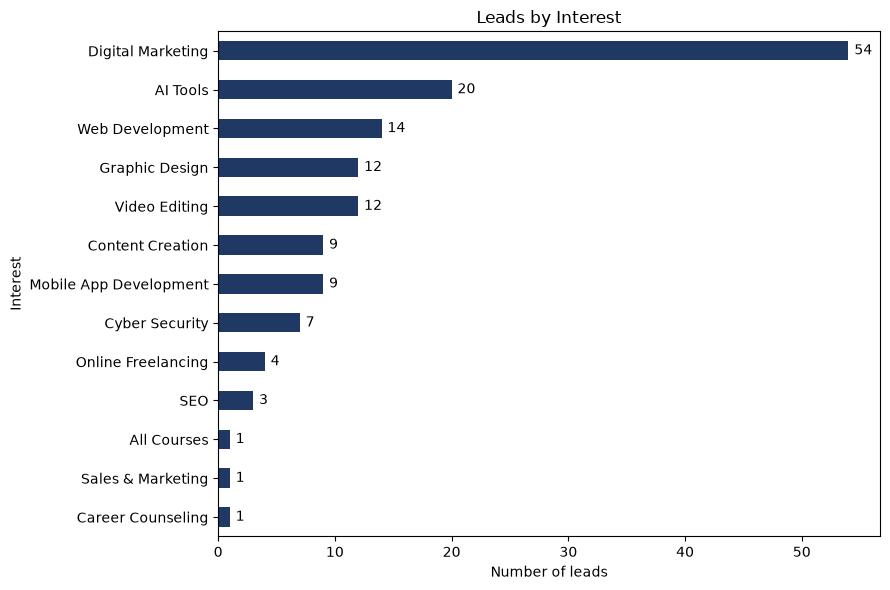

In [7]:
ax = interest_counts.sort_values().plot(kind="barh", figsize=(9, 6), color="#1F3864")
for i, v in enumerate(interest_counts.sort_values()):
    ax.text(v + 0.5, i, str(v), va="center")
plt.title("Leads by Interest")
plt.xlabel("Number of leads")
plt.tight_layout()
plt.savefig("chart1_interest.png", dpi=150)

### Chart 2, all locations

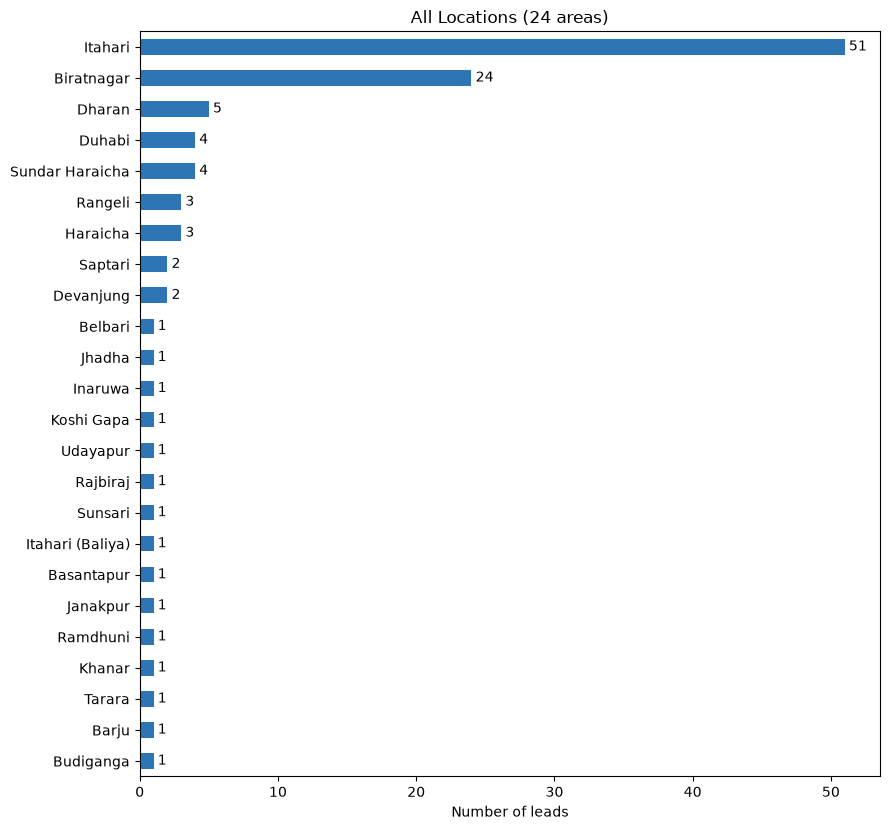

In [8]:
loc = df["Location"].value_counts()          
loc = loc.sort_values()

ax = loc.plot(kind="barh", figsize=(9, max(6, len(loc) * 0.35)), color="#2E75B6")
for i, v in enumerate(loc):
    ax.text(v + 0.3, i, str(v), va="center")

plt.title(f"All Locations ({len(loc)} areas)")
plt.xlabel("Number of leads")
plt.ylabel("")
plt.tight_layout()
plt.savefig("images/chart2_location.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3, pie of the all interests

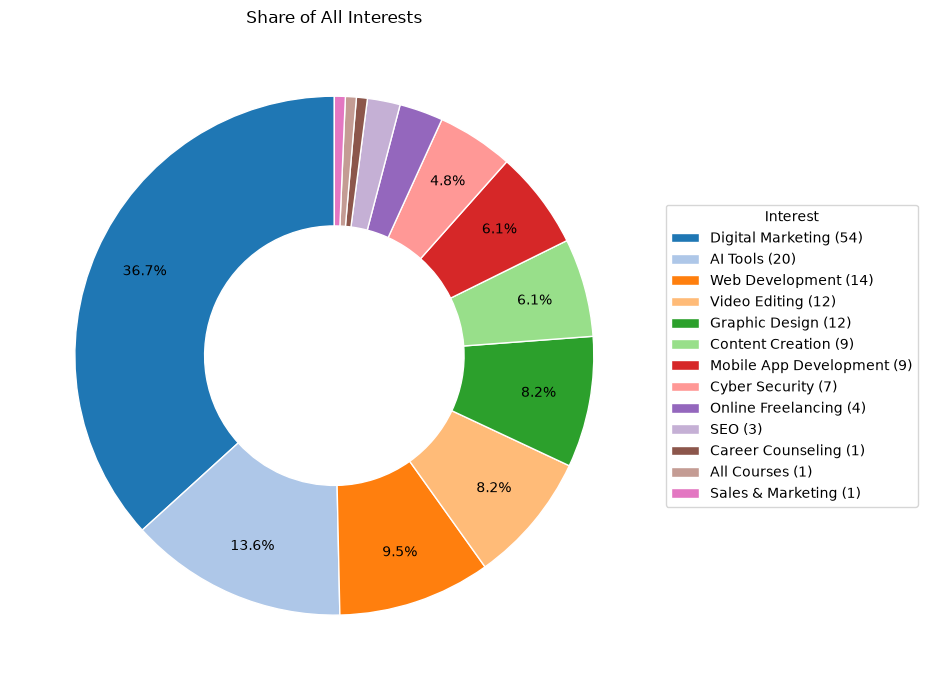

In [9]:
import matplotlib.pyplot as plt

data = interest_counts.sort_values(ascending=False)
colors = plt.cm.tab20.colors[:len(data)]

fig, ax = plt.subplots(figsize=(11, 7))

wedges, texts, autotexts = ax.pie(
    data,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",   # hide % on very small slices
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    wedgeprops={"width": 0.5, "edgecolor": "white"}
)

# Legend with the name and count of each interest
ax.legend(
    wedges,
    [f"{name} ({count})" for name, count in zip(data.index, data.values)],
    title="Interest",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

ax.set_title("Share of All Interests")
plt.tight_layout()
plt.savefig("chart3_pie_all.png", dpi=150, bbox_inches="tight")
plt.show()

### bar

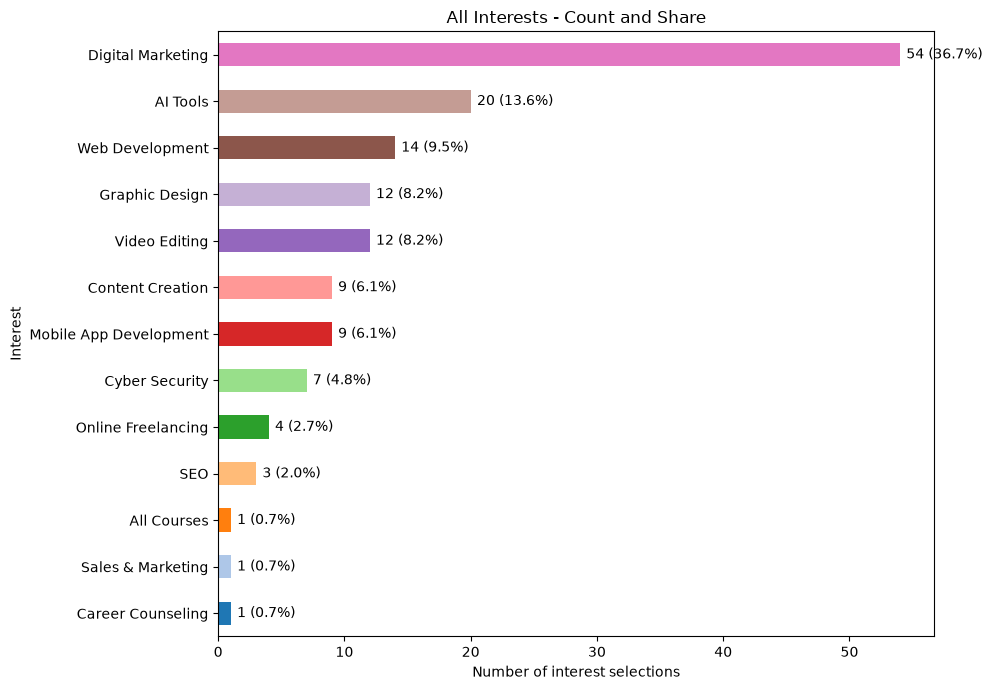

In [10]:
data = interest_counts.sort_values()
pct = (data / data.sum() * 100).round(1)

ax = data.plot(kind="barh", figsize=(10, 7), color=plt.cm.tab20.colors[:len(data)])
for i, (v, p) in enumerate(zip(data, pct)):
    ax.text(v + 0.5, i, f"{v} ({p}%)", va="center")

plt.title("All Interests - Count and Share")
plt.xlabel("Number of interest selections")
plt.tight_layout()
plt.savefig("chart3_bar_all.png", dpi=150)
plt.show()

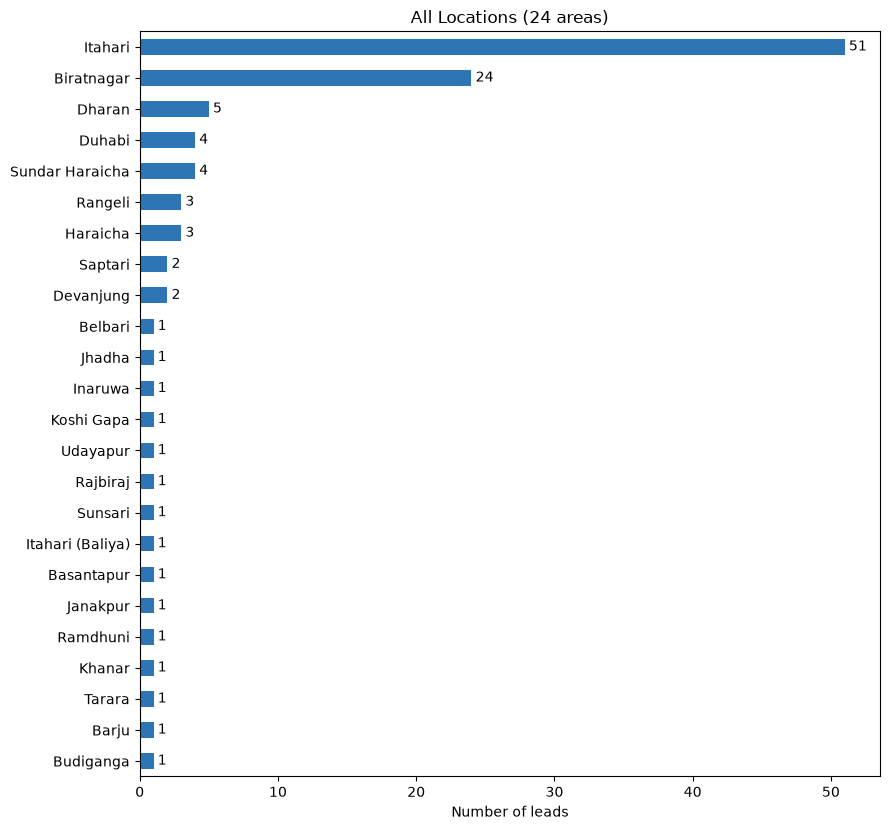

In [11]:
loc = df["Location"].value_counts()          
loc = loc.sort_values()

ax = loc.plot(kind="barh", figsize=(9, max(6, len(loc) * 0.35)), color="#2E75B6")
for i, v in enumerate(loc):
    ax.text(v + 0.3, i, str(v), va="center")

plt.title(f"All Locations ({len(loc)} areas)")
plt.xlabel("Number of leads")
plt.ylabel("")
plt.tight_layout()
plt.savefig("images/chart2_location.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 5, leads per source file

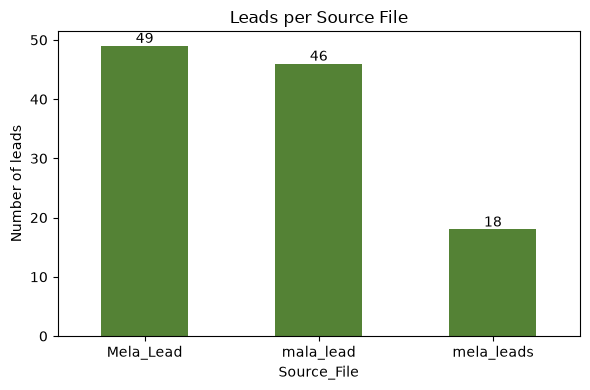

In [12]:
src = df["Source_File"].value_counts()
ax = src.plot(kind="bar", figsize=(6, 4), color="#548235", rot=0)
for i, v in enumerate(src):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.title("Leads per Source File")
plt.ylabel("Number of leads")
plt.tight_layout()
plt.savefig("chart5_source.png", dpi=150)

### Inspect the data

In [13]:
print(df.shape)

(113, 9)


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           113 non-null    int64  
 1   Name         113 non-null    str    
 2   Phone        113 non-null    str    
 3   Alt_Phone    1 non-null      str    
 4   Location     113 non-null    str    
 5   Ward         39 non-null     float64
 6   Interest     113 non-null    str    
 7   Source_File  113 non-null    str    
 8   Remarks      12 non-null     str    
dtypes: float64(1), int64(1), str(7)
memory usage: 8.1 KB


In [15]:
print(df.isnull().sum())

ID               0
Name             0
Phone            0
Alt_Phone      112
Location         0
Ward            74
Interest         0
Source_File      0
Remarks        101
dtype: int64


### Check duplicates

In [16]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate phone numbers:", df.duplicated(subset="Phone").sum())
df[df.duplicated(subset="Phone", keep=False)][["ID", "Name", "Phone", "Location"]]

Fully duplicate rows: 0
Duplicate phone numbers: 2


,ID,Name,Phone,Location
13,14,Pawan Ghimire,9842729208,Haraicha
14,15,Anuhav Ghimire,9842729208,Haraicha
32,33,Hasib Ansari,9823303517,Itahari
34,35,Hasib Ansari,9823303517,Barju


### Clean the text and fill missing values

In [17]:
df = df.copy()

for c in ["Name", "Location", "Interest", "Source_File"]:
    df[c] = df[c].astype(str).str.strip()

df["Name"] = df["Name"].str.title()
df["Phone"] = df["Phone"].str.replace(r"\D", "", regex=True)   # keep digits only
df["Alt_Phone"] = df["Alt_Phone"].fillna("")
df["Ward"] = df["Ward"].fillna(0).astype(int)                 # 0 = ward not given
df["Remarks"] = df["Remarks"].fillna("")

### Check phone numbers

In [18]:
df["Phone_Valid"] = df["Phone"].str.fullmatch(r"9\d{9}").astype(int)   # Nepal mobile: 10 digits, starts with 9
print(df["Phone_Valid"].value_counts())

Phone_Valid
1    113
Name: count, dtype: int64


### Remove duplicate phone numbers
Keep the first lead for each phone number and drop later repeats (113 leads to 111).

In [21]:
df_clean = df.drop_duplicates(subset="Phone", keep="first").reset_index(drop=True)
print(df_clean.shape)   

(111, 10)


### One column per interest (multi-hot encoding)

In [22]:
interest_list = df_clean["Interest"].str.split(", ")
exploded = interest_list.explode().str.strip()

mh = pd.crosstab(exploded.index, exploded).clip(upper=1)
mh = mh.drop(columns=["Not Specified", "Other"], errors="ignore")
mh.columns = ["Int_" + c.replace(" & ", "_and_").replace(" ", "_") for c in mh.columns]

df_clean = pd.concat([df_clean, mh], axis=1)
df_clean["Num_Interests"] = mh.sum(axis=1)
df_clean["Has_Interest"] = (df_clean["Num_Interests"] > 0).astype(int)
df_clean.head()

,ID,Name,Phone,Alt_Phone,Location,Ward,Interest,Source_File,Remarks,Phone_Valid,...,Int_Digital_Marketing,Int_Graphic_Design,Int_Mobile_App_Development,Int_Online_Freelancing,Int_SEO,Int_Sales_and_Marketing,Int_Video_Editing,Int_Web_Development,Num_Interests,Has_Interest
0,1,Krishna Karki,9851184642,,Haraicha,0,Content Creation,Mela_Lead,,1,...,0,0,0,0,0,0,0,0,1,1
1,2,Sarjak Gautam,9840513335,,Itahari,0,"Digital Marketing, Video Editing",Mela_Lead,,1,...,1,0,0,0,0,0,1,0,2,1
2,3,Happy Dev,9825382722,,Biratnagar,0,AI Tools,Mela_Lead,,1,...,0,0,0,0,0,0,0,0,1,1
3,4,Pema Ale Magar,9862355382,,Sundar Haraicha,0,"Digital Marketing, Career Counseling",Mela_Lead,,1,...,1,0,0,0,0,0,0,0,2,1
4,5,Nirmal Kc,9842156250,,Basantapur,0,Other,Mela_Lead,,1,...,0,0,0,0,0,0,0,0,0,0


### Group the locations

In [23]:
df_clean["Location_Group"] = df_clean["Location"]
df_clean["Is_Itahari"] = (df_clean["Location"].str.startswith("Itahari")).astype(int)
df_clean["Location_Group"].value_counts()

Location_Group
Itahari             51
Biratnagar          24
Dharan               5
Sundar Haraicha      4
Duhabi               4
Rangeli              3
Haraicha             2
Devanjung            2
Saptari              2
Basantapur           1
Ramdhuni             1
Janakpur             1
Budiganga            1
Tarara               1
Khanar               1
Itahari (Baliya)     1
Belbari              1
Jhadha               1
Inaruwa              1
Koshi Gapa           1
Udayapur             1
Rajbiraj             1
Sunsari              1
Name: count, dtype: int64

### Encode and build the final numeric table

In [24]:
loc_dummies = pd.get_dummies(df_clean["Location_Group"], prefix="Loc").astype(int)
df_clean["Source_Code"] = df_clean["Source_File"].astype("category").cat.codes

model_df = pd.concat([df_clean, loc_dummies], axis=1)

final = model_df.drop(columns=["ID", "Name", "Phone", "Alt_Phone", "Remarks",
                               "Interest", "Location", "Source_File", "Location_Group"])
print(final.shape)       # (111, 25)
final.head()

(111, 42)


,Ward,Phone_Valid,Int_AI_Tools,Int_All_Courses,Int_Career_Counseling,Int_Content_Creation,Int_Cyber_Security,Int_Digital_Marketing,Int_Graphic_Design,Int_Mobile_App_Development,...,Loc_Khanar,Loc_Koshi Gapa,Loc_Rajbiraj,Loc_Ramdhuni,Loc_Rangeli,Loc_Saptari,Loc_Sundar Haraicha,Loc_Sunsari,Loc_Tarara,Loc_Udayapur
0,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Save the cleaned data

In [25]:
df_clean.to_csv("leads_cleaned.csv", index=False)
final.to_csv("leads_model_ready.csv", index=False)

### Choose the features and target

In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

data = model_df[model_df["Has_Interest"] == 1].reset_index(drop=True)

y = data["Int_Digital_Marketing"]
loc_cols = [c for c in data.columns if c.startswith("Loc_")]
X = data[["Source_Code"] + loc_cols]         

### Compare models

In [27]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(200, random_state=42),
}
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    print(f"{name}: {s.mean():.3f} (+/- {s.std():.3f})")

Baseline: 0.505 (+/- 0.023)
LogReg: 0.610 (+/- 0.063)
RandomForest: 0.562 (+/- 0.082)


### Look at which features matter

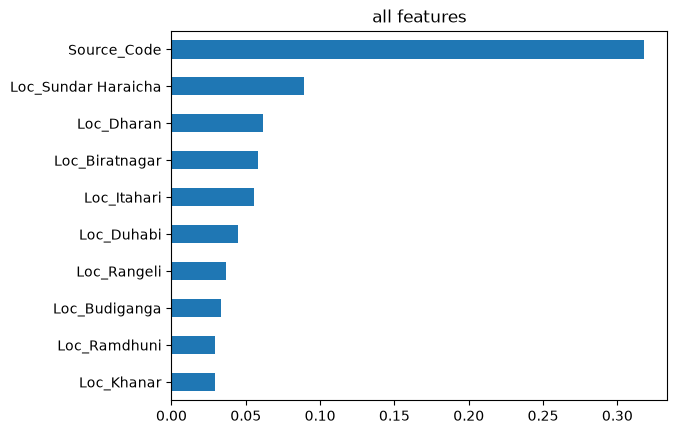

In [29]:
rf = RandomForestClassifier(200, random_state=42).fit(X, y)
pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10).plot(kind="barh")
plt.title("all features")
plt.show()

### cluster students by interest

In [31]:
from sklearn.cluster import KMeans

int_cols = [c for c in model_df.columns if c.startswith("Int_")]
Xc = model_df.loc[model_df["Has_Interest"] == 1, int_cols]

km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xc)
Xc = Xc.assign(Cluster=km.labels_)

print(Xc.groupby("Cluster").mean().round(2).T)  
print(Xc["Cluster"].value_counts())

Cluster                        0     1     2     3
Int_AI_Tools                0.00  1.00  0.00  0.00
Int_All_Courses             0.02  0.00  0.00  0.00
Int_Career_Counseling       0.02  0.00  0.00  0.00
Int_Content_Creation        0.02  0.00  0.00  0.33
Int_Cyber_Security          0.04  0.11  0.00  0.12
Int_Digital_Marketing       1.00  0.11  0.00  0.00
Int_Graphic_Design          0.02  0.05  0.25  0.29
Int_Mobile_App_Development  0.00  0.16  0.50  0.00
Int_Online_Freelancing      0.00  0.11  0.00  0.08
Int_SEO                     0.02  0.00  0.08  0.04
Int_Sales_and_Marketing     0.00  0.00  0.00  0.04
Int_Video_Editing           0.02  0.11  0.25  0.25
Int_Web_Development         0.00  0.21  0.83  0.00
Cluster
0    50
3    24
1    19
2    12
Name: count, dtype: int64


### Add the group names to each student

In [32]:
int_cols = [c for c in model_df.columns if c.startswith("Int_")]

clustered = model_df[model_df["Has_Interest"] == 1].copy()
clustered["Cluster"] = km.labels_

names = {0: "Digital Marketing", 1: "AI Tools", 2: "Developer", 3: "Creative / Media"}
clustered["Group"] = clustered["Cluster"].map(names)

### Percentage of students in each group

In [33]:
group_pct = (clustered["Group"].value_counts(normalize=True) * 100).round(1)
print(group_pct.astype(str) + " %")

Group
Digital Marketing    47.6 %
Creative / Media     22.9 %
AI Tools             18.1 %
Developer            11.4 %
Name: proportion, dtype: str


### Percentage of students who chose each interest

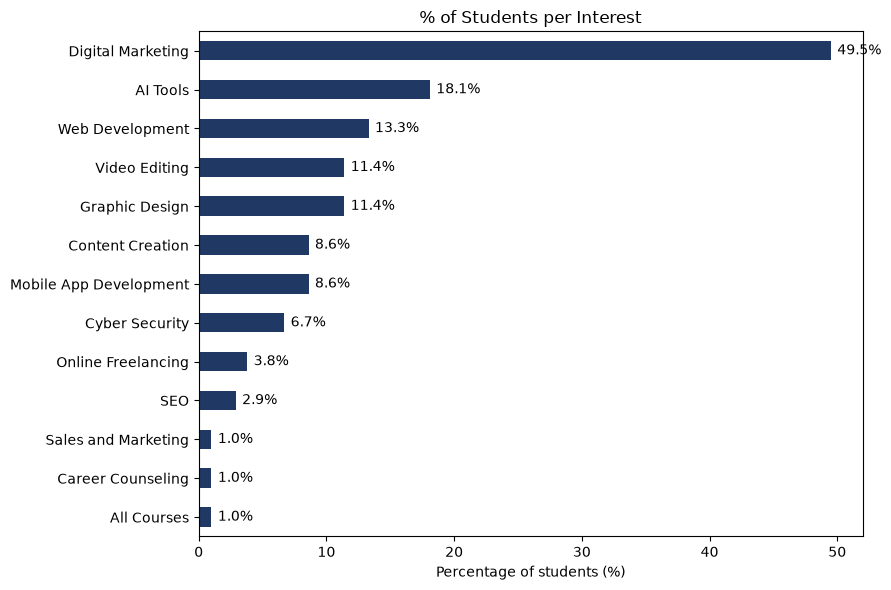

In [34]:
interest_pct = (clustered[int_cols].mean() * 100).round(1).sort_values()
interest_pct.index = interest_pct.index.str.replace("Int_", "").str.replace("_", " ")

ax = interest_pct.plot(kind="barh", figsize=(9, 6), color="#1F3864")
for i, v in enumerate(interest_pct):
    ax.text(v + 0.5, i, f"{v}%", va="center")
plt.title("% of Students per Interest")
plt.xlabel("Percentage of students (%)")
plt.tight_layout()
plt.savefig("images/chart8_interest_pct.png", dpi=150)
plt.show()

### Pie chart of the group share

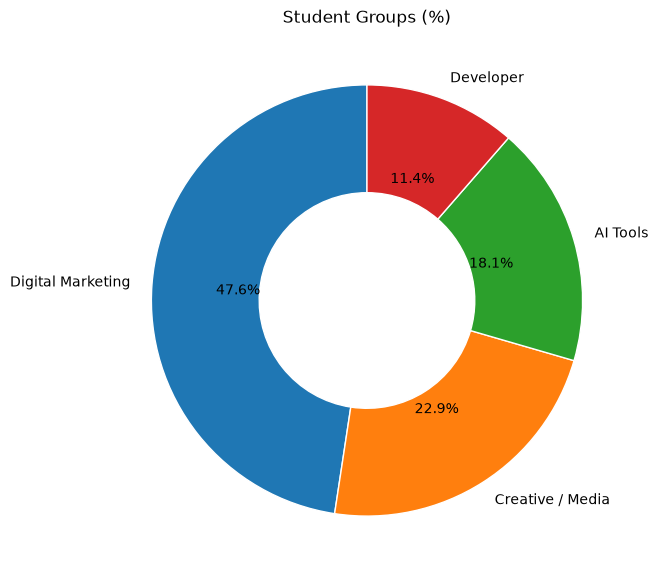

In [35]:
plt.figure(figsize=(7, 7))
plt.pie(group_pct, labels=group_pct.index, autopct="%1.1f%%",
        startangle=90, wedgeprops={"width": 0.5, "edgecolor": "white"})
plt.title("Student Groups (%)")
plt.savefig("images/chart9_group_pie.png", dpi=150, bbox_inches="tight")
plt.show()

### What each group wants, in percentages

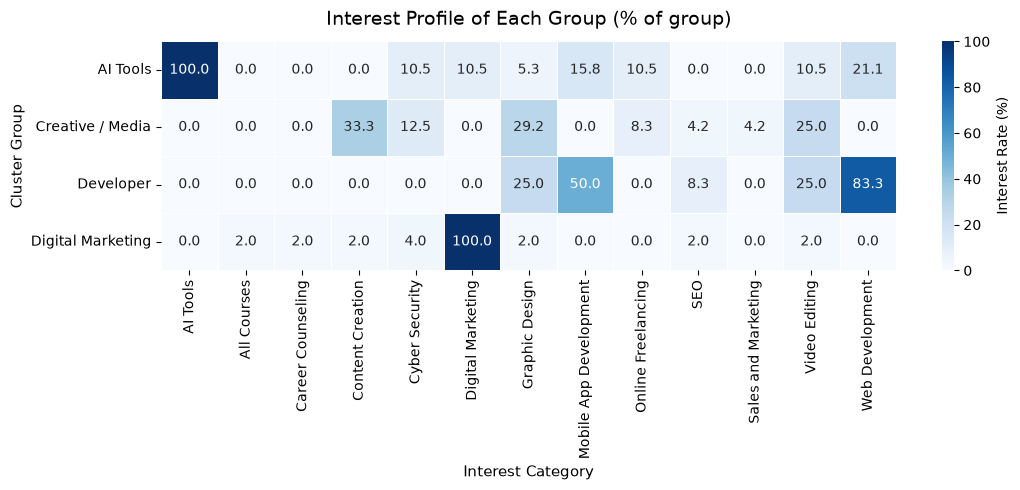

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate group interest percentages
profile = (clustered.groupby("Group")[int_cols].mean() * 100).round(1)
profile.columns = profile.columns.str.replace("Int_", "").str.replace("_", " ")

plt.figure(figsize=(11, 5))
sns.heatmap(
    profile,
    annot=True,
    fmt=".1f",  # Matches the round(1) precision
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Interest Rate (%)"},
)

plt.title("Interest Profile of Each Group (% of group)", fontsize=14, pad=12)
plt.xlabel("Interest Category", fontsize=11)
plt.ylabel("Cluster Group", fontsize=11)
plt.tight_layout()

plt.savefig("images/chart10_profile_pct.png", dpi=150, bbox_inches="tight")
plt.show()

### Where each group lives, in percentages

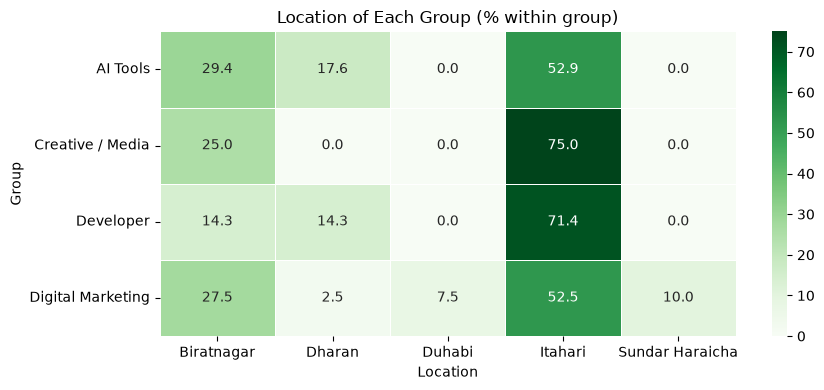

In [37]:
top_loc = clustered["Location"].value_counts().head(5).index
sub = clustered[clustered["Location"].isin(top_loc)]

loc_pct = pd.crosstab(sub["Group"], sub["Location"], normalize="index") * 100

plt.figure(figsize=(9, 4))
sns.heatmap(loc_pct, annot=True, fmt=".1f", cmap="Greens", linewidths=0.5)
plt.title("Location of Each Group (% within group)")
plt.tight_layout()
plt.savefig("images/chart11_location_pct.png", dpi=150)
plt.show()

### Data overview and quality

In [38]:
print("Rows, columns:", df_clean.shape)

quality = pd.DataFrame({
    "Missing": df_clean.replace("", np.nan).isnull().sum(),
    "Unique": df_clean.nunique()
})
quality["Missing_%"] = (quality["Missing"] / len(df_clean) * 100).round(1)
quality

with_int = model_df[model_df["Has_Interest"] == 1]
print(f"Leads with a clear interest: {len(with_int)} of {len(model_df)}")

Rows, columns: (111, 28)
Leads with a clear interest: 105 of 111


### How many interests does each student have?

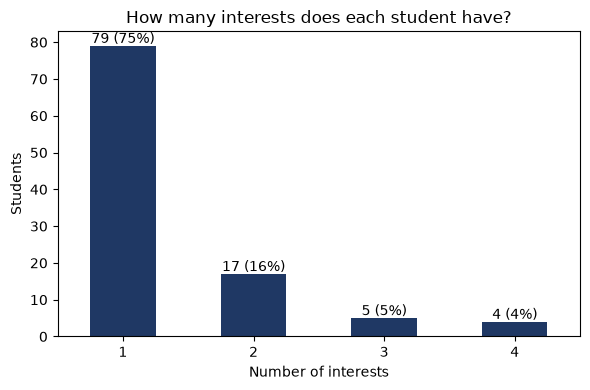

In [39]:
n = with_int["Num_Interests"].value_counts().sort_index()
ax = n.plot(kind="bar", color="#1F3864", rot=0, figsize=(6, 4))
for i, v in enumerate(n):
    ax.text(i, v + 0.8, f"{v} ({v/n.sum()*100:.0f}%)", ha="center")
plt.title("How many interests does each student have?")
plt.xlabel("Number of interests"); plt.ylabel("Students")
plt.tight_layout()
plt.savefig("images/eda1_num_interests.png", dpi=150)
plt.show()

### Most common interest choices

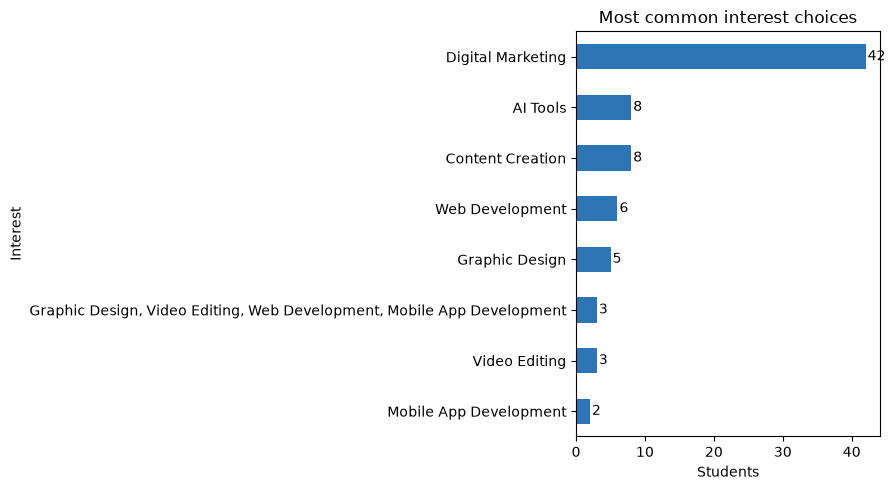

In [40]:
combo = with_int["Interest"].value_counts().head(8).sort_values()
ax = combo.plot(kind="barh", figsize=(9, 5), color="#2E75B6")
for i, v in enumerate(combo):
    ax.text(v + 0.3, i, str(v), va="center")
plt.title("Most common interest choices"); plt.xlabel("Students")
plt.tight_layout()
plt.savefig("images/eda2_combos.png", dpi=150)
plt.show()

### Which interests are chosen together?

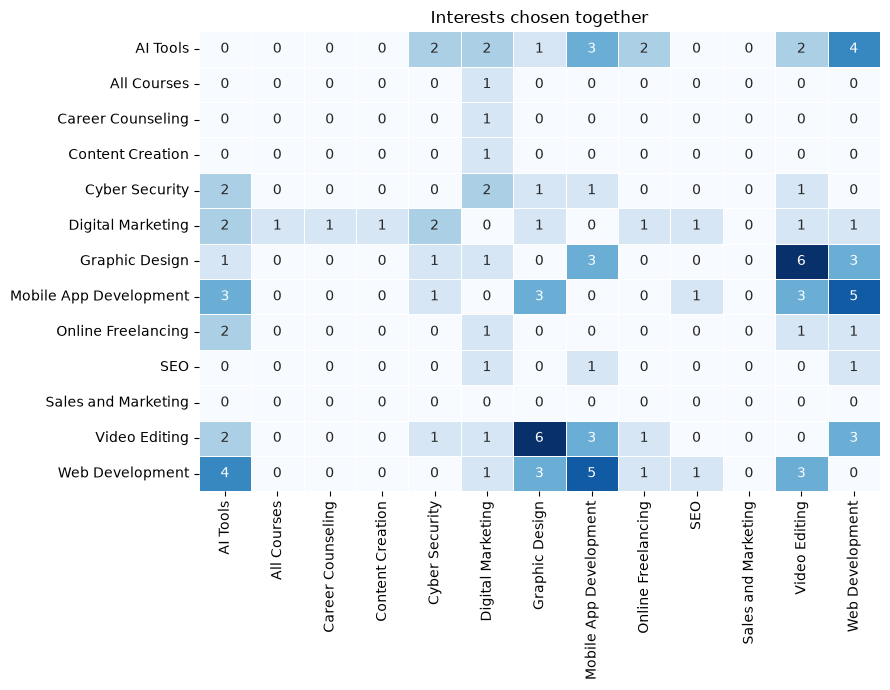

In [41]:
X = model_df[int_cols].astype(int)
co = X.T.dot(X)
arr = co.to_numpy().copy()
np.fill_diagonal(arr, 0)                       # hide the "with itself" counts
labels = [c.replace("Int_", "").replace("_", " ") for c in int_cols]
co = pd.DataFrame(arr, index=labels, columns=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=False)
plt.title("Interests chosen together")
plt.tight_layout()
plt.savefig("images/eda3_cooccurrence.png", dpi=150)
plt.show()

### Itahari compared with other areas (%)

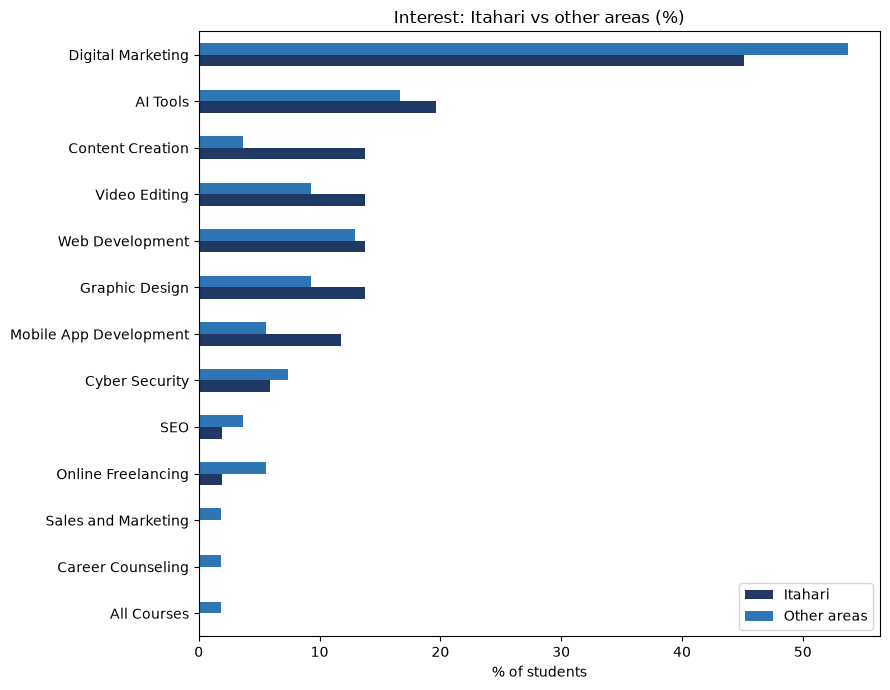

In [42]:
area = np.where(with_int["Is_Itahari"] == 1, "Itahari", "Other areas")
cmp = (with_int.groupby(area)[int_cols].mean() * 100).T
cmp.index = labels

cmp.sort_values("Itahari").plot(kind="barh", figsize=(9, 7), color=["#1F3864", "#2E75B6"])
plt.title("Interest: Itahari vs other areas (%)"); plt.xlabel("% of students")
plt.tight_layout()
plt.savefig("images/eda5_itahari.png", dpi=150)
plt.show()

### Biratnagar compared with other areas (%)

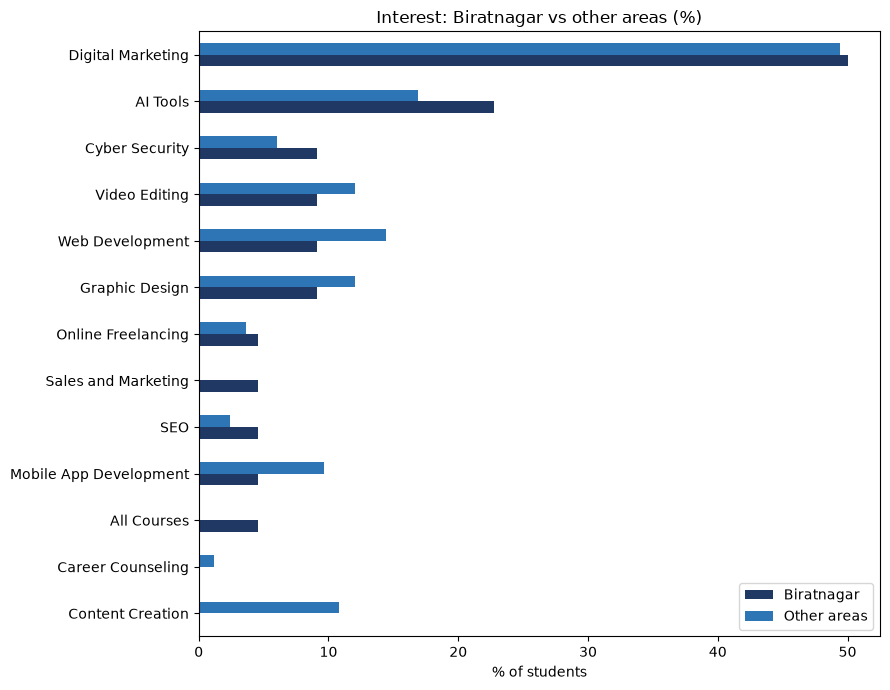

In [43]:
with_int = model_df[model_df["Has_Interest"] == 1]
labels = [c.replace("Int_", "").replace("_", " ") for c in int_cols]

area = np.where(with_int["Location"] == "Biratnagar", "Biratnagar", "Other areas")
cmp = (with_int.groupby(area)[int_cols].mean() * 100).T
cmp.index = labels

cmp.sort_values("Biratnagar").plot(kind="barh", figsize=(9, 7), color=["#1F3864", "#2E75B6"])
plt.title("Interest: Biratnagar vs other areas (%)")
plt.xlabel("% of students")
plt.tight_layout()
plt.savefig("images/eda5_biratnagar.png", dpi=150)
plt.show()

### Ward numbers

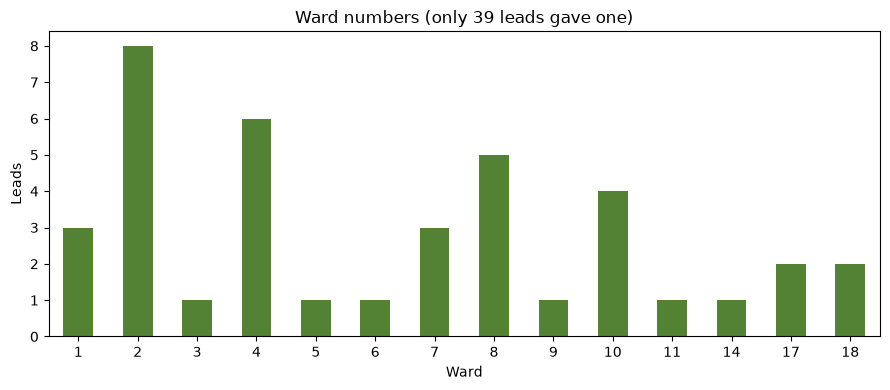

In [96]:
w = df_clean.loc[df_clean["Ward"] > 0, "Ward"].value_counts().sort_index()
w.plot(kind="bar", color="#548235", figsize=(9, 4), rot=0)
plt.title(f"Ward numbers (only {w.sum()} leads gave one)")
plt.xlabel("Ward"); plt.ylabel("Leads")
plt.tight_layout()
plt.savefig("images/eda6_ward.png", dpi=150)
plt.show()

### Load the train and test files
Read `train.csv` (88 leads) and `test.csv` (23 leads) into pandas. Phone numbers are read as text so no leading digits are lost. Students with no clear interest (`Has_Interest` = 0) are removed, leaving 84 training rows and 21 test rows with 25 columns each.

In [97]:
from sklearn.model_selection import train_test_split

keep = ["ID", "Name", "Phone", "Alt_Phone", "Location", "Ward", "Interest",
        "Source_File", "Remarks"] + int_cols + ["Num_Interests", "Has_Interest"]

full = model_df[keep].copy()
full["Digital_Marketing"] = full["Int_Digital_Marketing"]

train, test = train_test_split(full, test_size=0.2,
                               stratify=full["Digital_Marketing"], random_state=42)

train = train.sort_values("ID").reset_index(drop=True)
test  = test.sort_values("ID").reset_index(drop=True)

train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)

print("Train:", train.shape, " Test:", test.shape)   

Train: (88, 25)  Test: (23, 25)


In [98]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

# keep only students with a real interest
train = train[train["Has_Interest"] == 1]
test  = test[test["Has_Interest"] == 1]

print(train.shape, test.shape)   

(84, 25) (21, 25)


In [99]:
import os
print([f for f in os.listdir() if f in ("train.csv", "test.csv")])

['test.csv', 'train.csv']


In [100]:
features = ["Location", "Source_File"]
X_train, y_train = train[features], train["Digital_Marketing"]
X_test,  y_test  = test[features],  test["Digital_Marketing"]

### Build the model

In [101]:
model = Pipeline([
    ("encode", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])),
    ("model", LogisticRegression(C=0.3, max_iter=1000))
])

### Train it

In [102]:
model.fit(X_train, y_train)
print("Train accuracy:", round(accuracy_score(y_train, model.predict(X_train)), 3)) 

Train accuracy: 0.631


### Test it on the unseen test file

Use the trained model to predict Digital Marketing for the 21 test students, whom it has never seen. Then compare the predictions with what they really chose, using accuracy and a confusion matrix. Result: about 67% accuracy, against 50% for guessing.

In [ ]:
pred = model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, pred), 3))    
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=["Not DM", "Digital Marketing"]))

Test accuracy: 0.667
[[8 2]
 [5 6]]
                   precision    recall  f1-score   support

           Not DM       0.62      0.80      0.70        10
Digital Marketing       0.75      0.55      0.63        11

         accuracy                           0.67        21
        macro avg       0.68      0.67      0.66        21
     weighted avg       0.69      0.67      0.66        21



### Predict for a new student

In [104]:
new = pd.DataFrame([{"Location": "Itahari", "Source_File": "Mela_Lead"}])
chance = model.predict_proba(new)[0, 1] * 100
print(f"Chance of Digital Marketing: {chance:.1f}%")     

Chance of Digital Marketing: 60.3%


### Features and all the course targets
Features (`X`) are what the model looks at: `Location` and `Source_File`. Targets (`Y`) are what it tries to predict: one 0/1 column for each course (the `Int_` columns), where 1 means the student chose that course.

In [105]:
features = ["Location", "Source_File"]
courses = [c for c in train.columns if c.startswith("Int_")]     

X_train, Y_train = train[features], train[courses]
X_test,  Y_test  = test[features],  test[courses]

print(Y_train.sum())       

Int_AI_Tools                  15
Int_All_Courses                1
Int_Career_Counseling          0
Int_Content_Creation           7
Int_Cyber_Security             6
Int_Digital_Marketing         41
Int_Graphic_Design             9
Int_Mobile_App_Development     6
Int_Online_Freelancing         4
Int_SEO                        1
Int_Sales_and_Marketing        1
Int_Video_Editing             10
Int_Web_Development           11
dtype: int64


In [106]:
ok = [c for c in courses if Y_train[c].sum() >= 5]
print("Courses used:", [c.replace("Int_", "") for c in ok])

Courses used: ['AI_Tools', 'Content_Creation', 'Cyber_Security', 'Digital_Marketing', 'Graphic_Design', 'Mobile_App_Development', 'Video_Editing', 'Web_Development']


### Build and train the model
Turn Location and Source_File into 0/1 columns (one-hot encoding), then train one Logistic Regression model for each of the 8 courses. The model learns from the training students only.

In [107]:
def make_model():
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])
    return Pipeline([("pre", pre),
                     ("m", MultiOutputClassifier(LogisticRegression(C=0.3, max_iter=1000)))])

model = make_model()
model.fit(X_train, Y_train[ok])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.",list,"[array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['Location','Source_File']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not

### Test every course
Predict each of the 8 courses for the 21 test students. For each course, compare accuracy, precision, recall and AUC with the "always say no" accuracy. Result: only Digital Marketing beats that baseline, and the other courses are never predicted.

In [ ]:
proba = np.column_stack([p[:, 1] for p in model.predict_proba(X_test)])
pred = (proba >= 0.5).astype(int)

rows = []
for i, c in enumerate(ok):
    y = Y_test[c]
    auc = roc_auc_score(y, proba[:, i]) if y.nunique() > 1 else np.nan
    rows.append([c.replace("Int_", "").replace("_", " "),
                 int(Y_train[c].sum()), int(y.sum()),
                 round(1 - y.mean(), 3),                       
                 round(accuracy_score(y, pred[:, i]), 3),
                 round(precision_score(y, pred[:, i], zero_division=0), 3),
                 round(recall_score(y, pred[:, i], zero_division=0), 3),
                 round(auc, 3), int(pred[:, i].sum())])

results = pd.DataFrame(rows, columns=["Course", "Train_n", "Test_n", "Always_No_Acc",
                                      "Accuracy", "Precision", "Recall", "AUC", "Predicted_Yes"])
results

,Course,Train_n,Test_n,Always_No_Acc,Accuracy,Precision,Recall,AUC,Predicted_Yes
0,AI Tools,15,4,0.810,0.810,0.00,0.000,0.338,0
1,Content Creation,7,2,0.905,0.905,0.00,0.000,0.724,0
2,Cyber Security,6,1,0.952,0.952,0.00,0.000,0.025,0
3,Digital Marketing,41,11,0.476,0.667,0.75,0.545,0.645,8
4,Graphic Design,9,3,0.857,0.857,0.00,0.000,0.870,0
5,Mobile App Development,6,3,0.857,0.857,0.00,0.000,0.667,0
6,Video Editing,10,2,0.905,0.905,0.00,0.000,0.816,0
7,Web Development,11,3,0.857,0.857,0.00,0.000,0.565,0


### Is the best course guess right?

In [109]:
top = proba.argmax(axis=1)
hit = [Y_test[ok[t]].iloc[i] == 1 for i, t in enumerate(top)]
print("Top prediction is one of the student's courses:", round(np.mean(hit), 3))
print("Always guessing Digital Marketing           :", round(Y_test["Int_Digital_Marketing"].mean(), 3))

Top prediction is one of the student's courses: 0.524
Always guessing Digital Marketing           : 0.524


### Predict all courses for a new student

In [110]:
new = pd.DataFrame([{"Location": "Itahari", "Source_File": "Mela_Lead"}])
p = np.column_stack([q[:, 1] for q in model.predict_proba(new)])[0]

chance = pd.Series(p * 100, index=[c.replace("Int_", "").replace("_", " ") for c in ok])
chance.round(1).sort_values(ascending=False)

Digital Marketing         60.3
AI Tools                  14.2
Video Editing             12.0
Content Creation          11.9
Graphic Design            10.0
Web Development            6.7
Cyber Security             6.4
Mobile App Development     6.1
dtype: float64

### Prepare the whole dataset
Join the train and test files back into one table of all 111 leads, sorted by ID. No leads are removed, including the 6 with no clear interest.

In [8]:
import numpy as np
from sklearn.model_selection import cross_val_predict, StratifiedKFold, KFold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
full = pd.concat([train, test], ignore_index=True).sort_values("ID").reset_index(drop=True)

features = ["Location", "Source_File"]
print(full.shape)      

(111, 25)


### Confusion matrix for Digital Marketing (whole dataset)
Shows how many of the 111 leads the model predicted right and wrong for Digital Marketing. Each lead is predicted by a model that did not train on it (5-fold cross-validation). Result: 71 correct and 40 wrong, an accuracy of about 64%.

[[41 18]
 [22 30]]


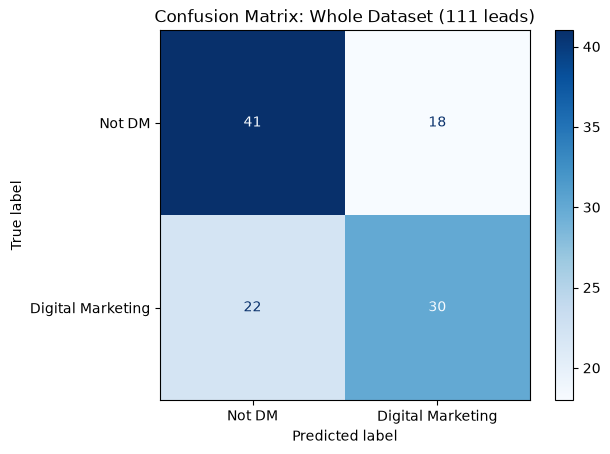

Accuracy : 0.64
Precision: 0.625
Recall   : 0.577


In [6]:
def make_model():
    return Pipeline([
        ("encode", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])),
        ("model", LogisticRegression(C=0.3, max_iter=1000))])

pred_dm = cross_val_predict(make_model(), full[features], full["Digital_Marketing"],
                            cv=StratifiedKFold(5, shuffle=True, random_state=42))

cm = confusion_matrix(full["Digital_Marketing"], pred_dm)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=["Not DM", "Digital Marketing"]).plot(cmap="Blues")
plt.title("Confusion Matrix: Whole Dataset (111 leads)")
plt.savefig("images/cm_whole.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Accuracy :", round((tn + tp) / cm.sum(), 3))
print("Precision:", round(tp / (tp + fp), 3))
print("Recall   :", round(tp / (tp + fn), 3))

### Confusion matrix for every course (whole dataset)
One small matrix per course, using all 111 leads. Each lead is predicted by a model that did not train on it (5-fold cross-validation). Digital Marketing is the only course with predicted "Yes" cases. The other courses are never predicted, because too few students chose them.

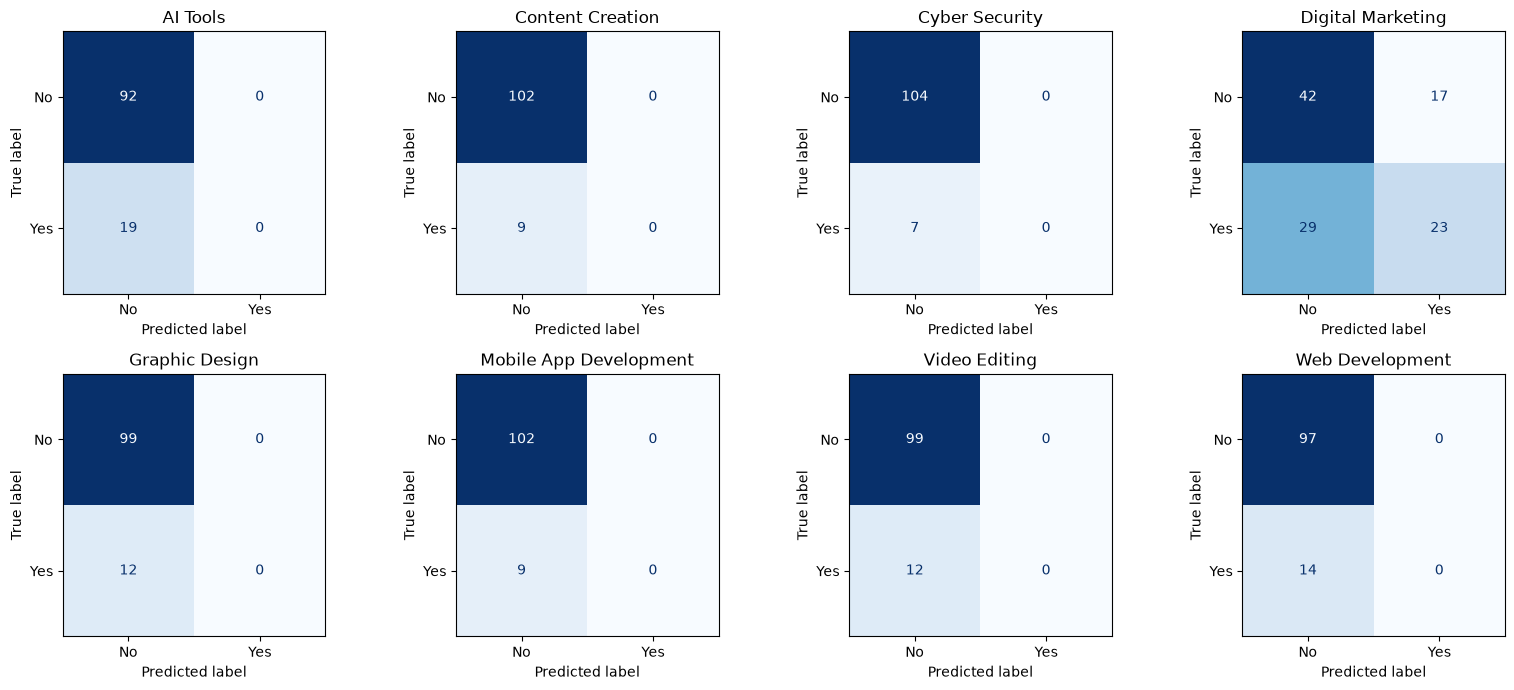

In [7]:
courses = [c for c in full.columns if c.startswith("Int_") and full[c].sum() >= 5]

def make_multi():
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])
    return Pipeline([("pre", pre),
                     ("m", MultiOutputClassifier(LogisticRegression(C=0.3, max_iter=1000)))])

chance = np.zeros((len(full), len(courses)))
for a, b in KFold(5, shuffle=True, random_state=42).split(full):
    m = make_multi().fit(full.loc[a, features], full.loc[a, courses])
    chance[b] = np.column_stack([q[:, 1] for q in m.predict_proba(full.loc[b, features])])

pred = (chance >= 0.5).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (i, c) in zip(axes.ravel(), enumerate(courses)):
    cm_c = confusion_matrix(full[c], pred[:, i], labels=[0, 1])
    ConfusionMatrixDisplay(cm_c, display_labels=["No", "Yes"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(c.replace("Int_", "").replace("_", " "))
plt.tight_layout()
plt.savefig("images/cm_all_courses.png", dpi=150, bbox_inches="tight")
plt.show()